In [80]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
df = pd.read_csv("/content/drive/MyDrive/Concept and technology of AI/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [83]:
df.shape

(21613, 21)

# 3.2.1.1 Dataset Description

# (a) When and by whom the dataset was created:
# The King County House Sales dataset was created by King County, Washington (USA),
# containing house sales records from May 2014 to May 2015.
# It is commonly used for real estate price prediction and regression analysis.


# 3.2.1.1 Dataset Description
# (b) How and from where the dataset was accessed:
# The dataset was accessed as a CSV file provided for this coursework
# and is publicly available through platforms such as Kaggle.


# 3.2.1.1 Dataset Description
# (c) Alignment with the chosen UNSDG:
# This dataset aligns with United Nations Sustainable Development Goal 11:
# "Sustainable Cities and Communities".
# Analyzing housing prices helps in understanding urban development,
# housing affordability, and sustainable city planning.

# 3.2.1.1 Dataset Description
# (d) List of attributes (columns) with brief descriptions:
columns_description = {
    "id": "Unique identifier for each house",
    "date": "Date the house was sold",
    "price": "Sale price of the house (target variable)",
    "bedrooms": "Number of bedrooms",
    "bathrooms": "Number of bathrooms",
    "sqft_living": "Living area in square feet",
    "sqft_lot": "Lot size in square feet",
    "floors": "Number of floors",
    "waterfront": "Whether the house has a waterfront view",
    "view": "Quality of the view",
    "condition": "Condition of the house",
    "grade": "Overall grade given to the housing unit",
    "sqft_above": "Square feet above ground",
    "sqft_basement": "Square feet of basement",
    "yr_built": "Year the house was built",
    "yr_renovated": "Year the house was renovated",
    "zipcode": "ZIP code of the house location",
    "lat": "Latitude",
    "long": "Longitude",
    "sqft_living15": "Living area in 2015",
    "sqft_lot15": "Lot size in 2015"
}

columns_description


In [84]:
# 3.2.1.1.4 Potential Questions the Dataset Can Answer

potential_questions = [
    "How do house features such as size, number of bedrooms, and location affect house prices?",
    "Does having a waterfront or better view significantly increase house prices?",
    "How does the age of a house influence its market value?"
]

potential_questions

['How do house features such as size, number of bedrooms, and location affect house prices?',
 'Does having a waterfront or better view significantly increase house prices?',
 'How does the age of a house influence its market value?']

In [85]:
# 3.2.1.1.5
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

2. Exploratory Data Analysis (EDA):

In [86]:
# 3.2.1.2
df.isna().sum().sort_values(ascending=False).head(10)
df.duplicated().sum()
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312049,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


In [87]:
df["date"] = pd.to_datetime(df["date"].str[:8], format="%Y%m%d", errors="coerce")
df[["date"]].head()

,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


In [88]:
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month
df = df.drop(columns=["id", "date"])


In [90]:
# Check duplicates first
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Confirm removal
print("Duplicate rows after removal:", df.duplicated().sum())


Duplicate rows before removal: 0
Duplicate rows after removal: 0


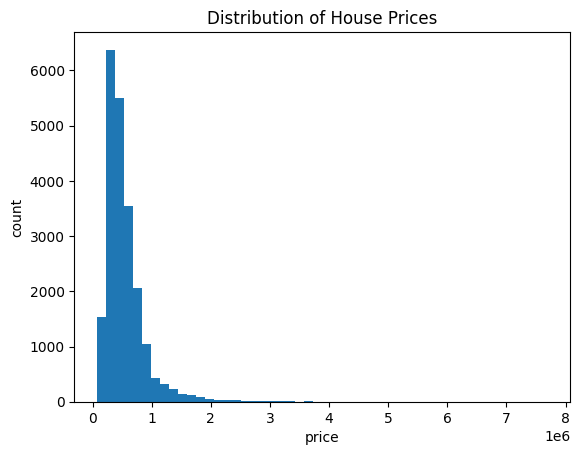

In [ ]:
plt.figure()
plt.hist(df["price"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

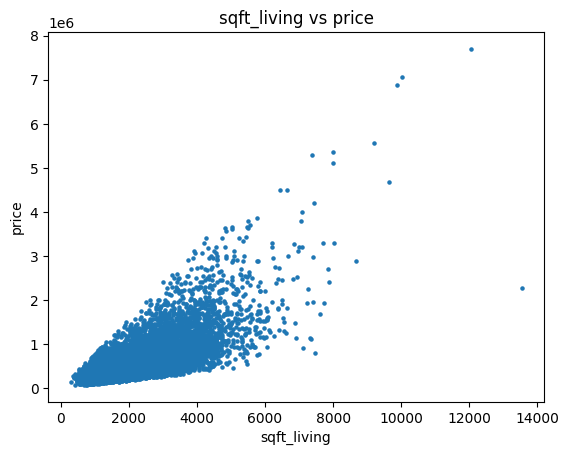

In [ ]:
plt.figure()
plt.scatter(df["sqft_living"], df["price"], s=5)
plt.title("sqft_living vs price")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

<Figure size 640x480 with 0 Axes>

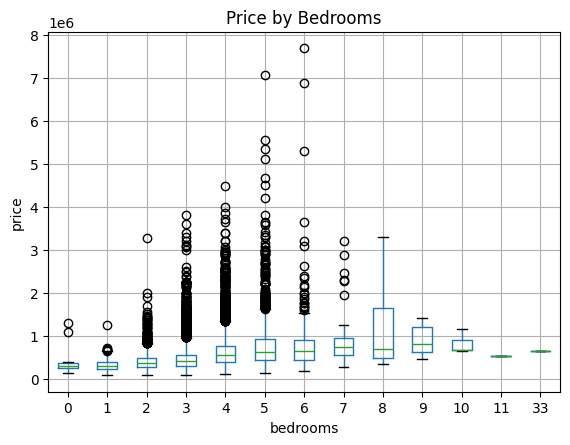

In [ ]:
plt.figure()
df.boxplot(column="price", by="bedrooms")
plt.title("Price by Bedrooms")
plt.suptitle("")
plt.xlabel("bedrooms")
plt.ylabel("price")
plt.show()

2. Build a Neural Network Model for Regression

In [ ]:
#2.1
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#2.2
cat_cols = ["zipcode"] if "zipcode" in X.columns else []
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

nn_model = Pipeline(steps=[
    ("prep", preprocess),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        random_state=42,
        max_iter=300
    ))
])

nn_model.fit(X_train, y_train);

In [ ]:
#2.3
def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

yhat_train = nn_model.predict(X_train)
yhat_test  = nn_model.predict(X_test)

train_mae, train_mse, train_rmse, train_r2 = reg_metrics(y_train, yhat_train)
test_mae, test_mse, test_rmse, test_r2 = reg_metrics(y_test, yhat_test)

train_mae, train_rmse, train_r2, test_mae, test_rmse, test_r2

3. Build Primary Machine Learning Models

In [ ]:
#3.1
lin_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
lin_test_pred = lin_model.predict(X_test)
reg_metrics(y_test, lin_test_pred)


(98275.74505465264,
 29000763278.639515,
 np.float64(170296.10470776926),
 0.8081664639632736)

In [ ]:
# 3.2 Random Forest Regressor
rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train);

In [ ]:
rf_test_pred = rf_model.predict(X_test)
reg_metrics(y_test, rf_test_pred)

(72265.97451538284,
 22240189166.910805,
 np.float64(149131.44928857495),
 0.8528861434086248)

In [ ]:
# 3.2.3 Build Primary Machine Learning Models (Two Classical ML Models)

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

primary_model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

primary_model_comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,126963.208633,212036.165380,0.702604
1,Random Forest,72900.904987,150185.682349,0.850799


4. Hyperparameter Optimization with Cross-Validation

In [ ]:
# Hyperparameter Optimization with Cross-Validation
# 3.2.4.1 Identify key hyperparameters (for both models)
lr_param_grid = {
    "fit_intercept": [True, False]
}

rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}


In [ ]:
# 3.2.4.2 Tune on a subset to reduce time

X_train_sub = X_train.sample(n=6000, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index]

grid_rf.fit(X_train_sub, y_train_sub)

grid_rf.best_params_, grid_rf.best_score_


({'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300},
 np.float64(0.8456353554977862))

In [ ]:
# 3.2.4.3 Report best hyperparameters and corresponding CV scores

hyperparameter_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Best Hyperparameters": [grid_lr.best_params_, grid_rf.best_params_],
    "Best CV R2 Score": [grid_lr.best_score_, grid_rf.best_score_]
})

hyperparameter_results


,Model,Best Hyperparameters,Best CV R2 Score
0,Linear Regression,{'fit_intercept': True},0.699312
1,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.845635


5. Feature Selection

In [ ]:
# 3.2.5 Feature Selection

# Get best Random Forest model from hyperparameter tuning
best_rf = grid_rf.best_estimator_

# Extract feature importance values
rf_importance = best_rf.feature_importances_

# Create feature importance table
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
8,grade,0.343102
2,sqft_living,0.206574
14,lat,0.154116
15,long,0.074862
11,yr_built,0.041044
16,sqft_living15,0.037971
9,sqft_above,0.033818
13,zipcode,0.018156
3,sqft_lot,0.014672
17,sqft_lot15,0.014508


In [ ]:
# Select top 5 important features
selected_features = feature_importance_df["Feature"].head(5).tolist()

selected_features

['grade', 'sqft_living', 'lat', 'long', 'yr_built']

In [ ]:
# Reduce training and testing data to selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

## #Feature selection was performed using the embedded method from Random Forest. This approach ranks features based on their contribution to reducing prediction error, allowing the most informative variables to be identified. The top-ranked features were selected because they carry the highest predictive power. To ensure a fair and consistent comparison between models, the same set of selected features was used for both Linear Regression and Random Forest.

#6. Final Models and Comparative Analysis

In [ ]:
# 3.2.6.1 Rebuild final models

final_lr = grid_lr.best_estimator_
final_rf = grid_rf.best_estimator_


In [ ]:
# 3.2.6.2 Train final models using selected features

final_lr.fit(X_train_selected, y_train)
final_rf.fit(X_train_selected, y_train)

# Predictions
lr_pred = final_lr.predict(X_test_selected)
rf_pred = final_rf.predict(X_test_selected)

# Evaluation
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)


In [ ]:
# 3.2.6.3 Final comparison table

final_model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Features Used": [
        f"Selected ({len(selected_features)})",
        f"Selected ({len(selected_features)})"
    ],
    "CV Score": [grid_lr.best_score_, grid_rf.best_score_],
    "Test RMSE": [lr_rmse, rf_rmse],
    "Test R-squared": [lr_r2, rf_r2]
})

final_model_comparison


,Model,Features Used,CV Score,Test RMSE,Test R-squared
0,Linear Regression,Selected (5),0.699312,233482.701474,0.639401
1,Random Forest,Selected (5),0.845635,157285.525083,0.836359
